In [1]:
from show_img import show_img
import numpy as np
import cv2
from matplotlib import pyplot as plt

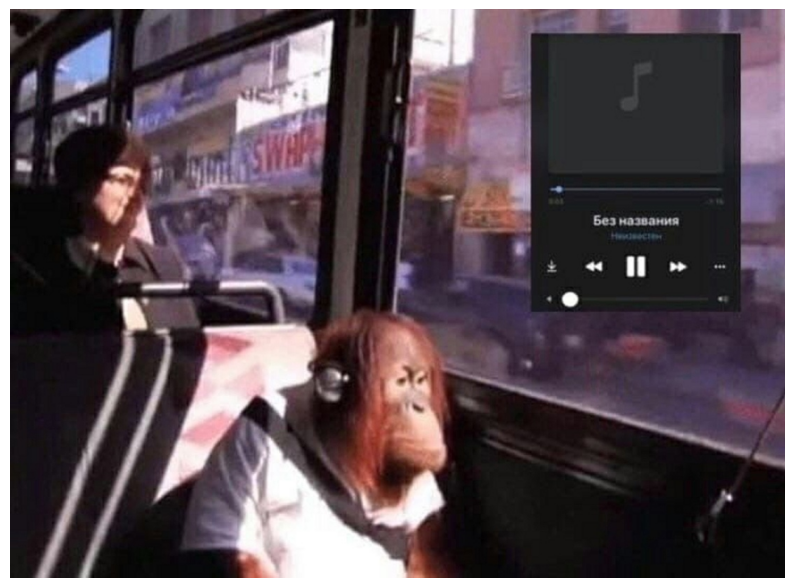

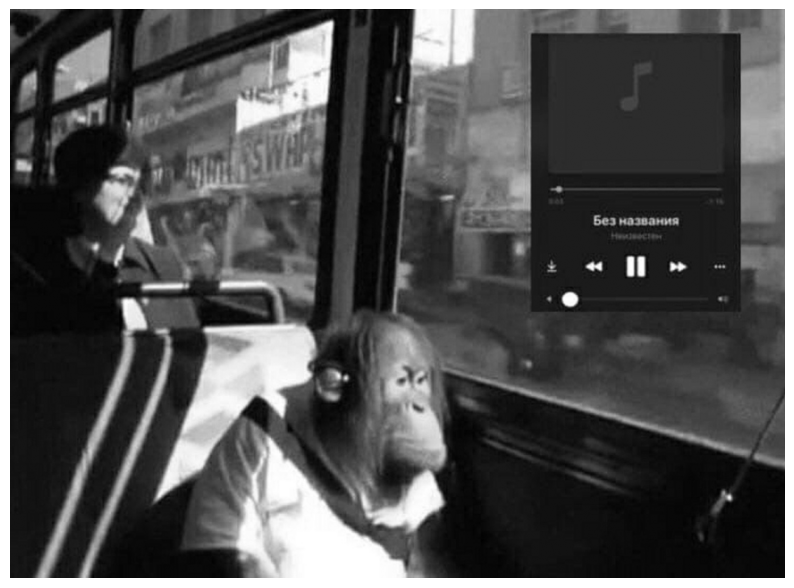

In [2]:
img = cv2.imread("bibizyana.jpg")
img_grayscale = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
show_img(img)
show_img(img_grayscale)

## 1. Гистограмма грейскейла

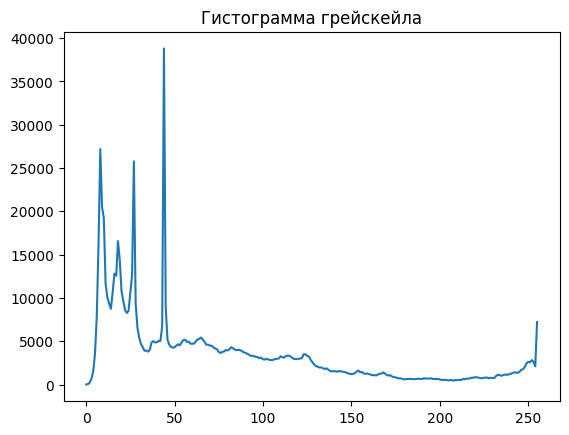

In [3]:
hist = cv2.calcHist([img_grayscale], [0], None, [256], [0, 256])
plt.plot(hist)
plt.title('Гистограмма грейскейла')
plt.show()

## 2. Гистограммы цветовых каналов

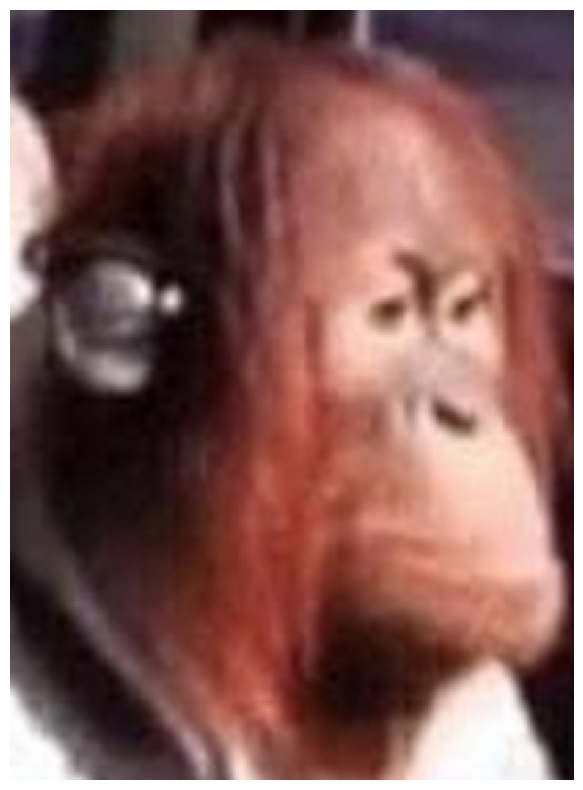

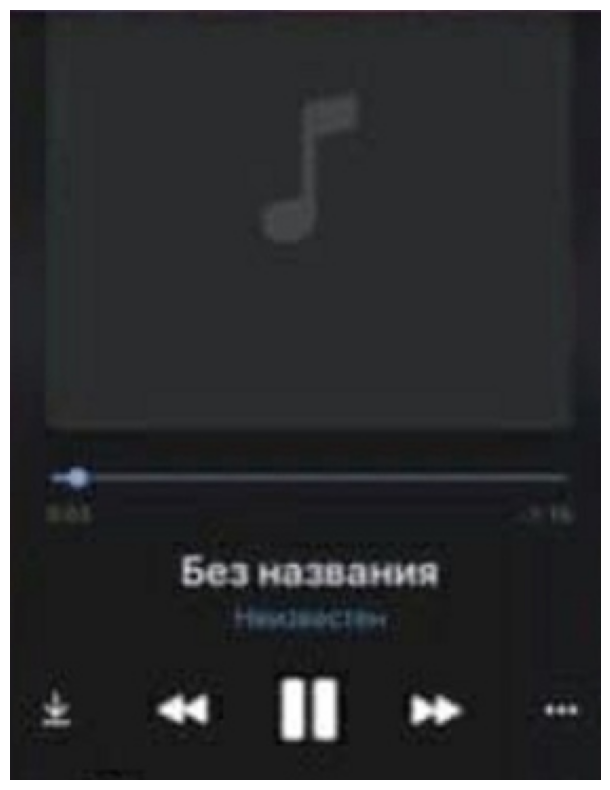

In [4]:
# подготовка фрагментов и масок для них
img_crop1 = img[420:700, 420:625]
show_img(img_crop1)
mask_monkey_head = np.zeros(img.shape[:2], np.uint8)
mask_monkey_head[420:700, 420:625] = 255

img_crop2 = img[35:400, 750:1030]
show_img(img_crop2)
mask_player = np.zeros(img.shape[:2], np.uint8)
mask_player[35:400, 750:1030] = 255

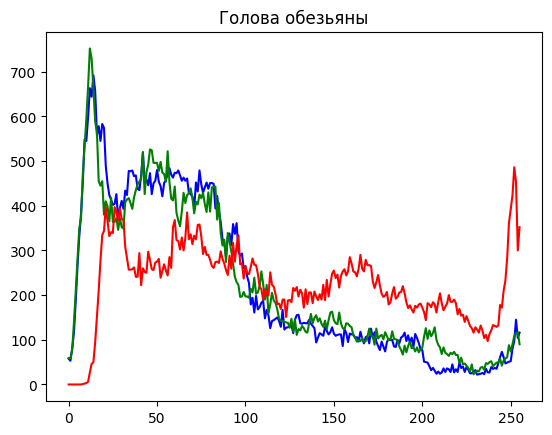

In [5]:
color = ('b', 'g', 'r')
for i, col in enumerate(color):
    hist1 = cv2.calcHist([img], [i], mask_monkey_head, [256], [0, 256])
    plt.plot(hist1, color = col)
plt.title("Голова обезьяны")
plt.show()

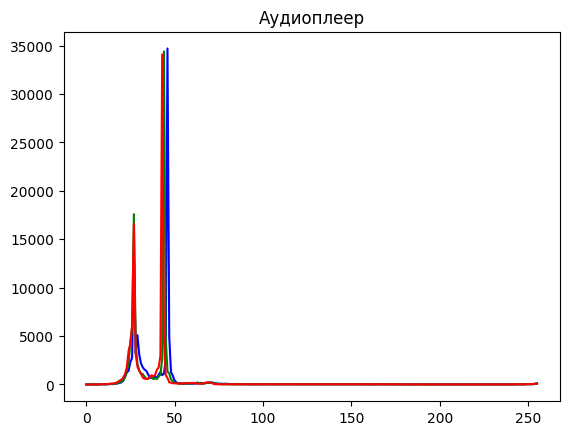

In [6]:
for i, col in enumerate(color):
    hist1 = cv2.calcHist([img], [i], mask_player, [256], [0, 256])
    plt.plot(hist1, color = col)
plt.title("Аудиоплеер")
plt.show()

## 3. Контрастирование гистограммы

### Искусственное засветление

In [7]:
value = -50
img_bright = cv2.add(img, np.array([value, value, value]))

### Контрастирование гистаграммы цветного изображения

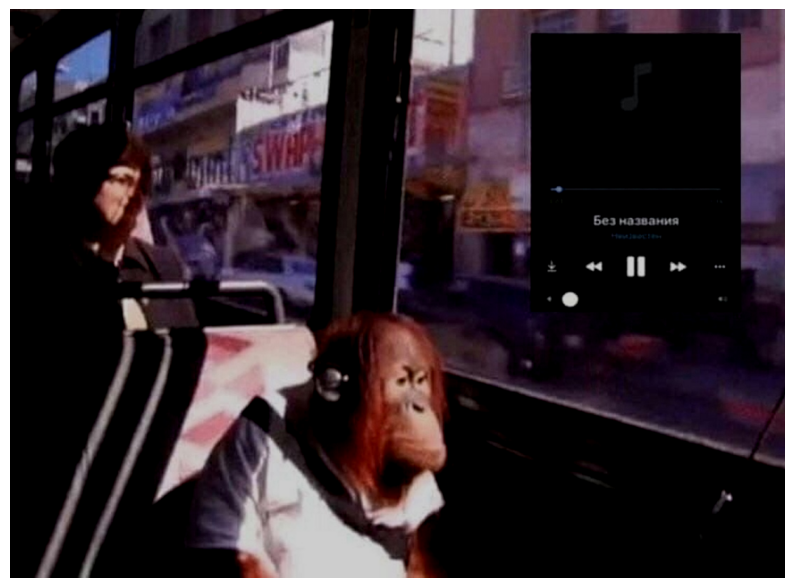

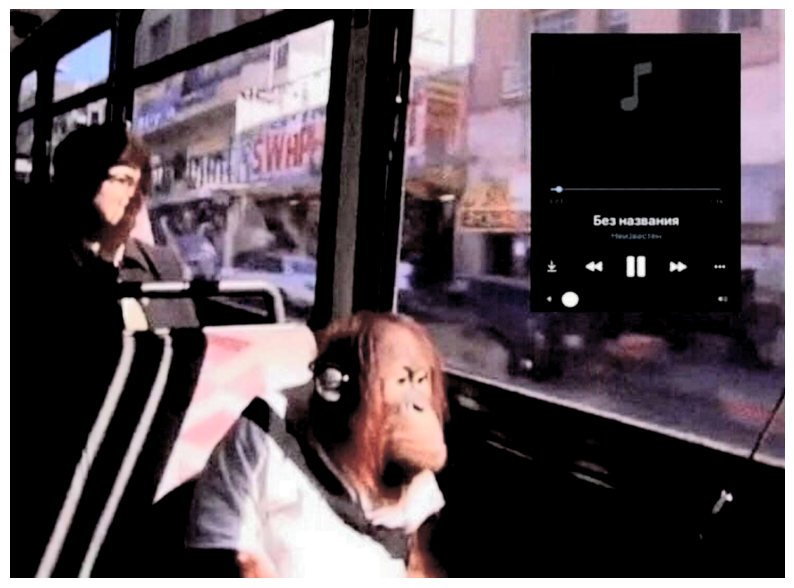

In [8]:
img_bright_yuv = cv2.cvtColor(img_bright, cv2.COLOR_BGR2YUV)
img_bright_yuv[:,:,0] = cv2.equalizeHist(img_bright_yuv[:,:,0])
img_bright_eql = cv2.cvtColor(img_bright_yuv, cv2.COLOR_YUV2BGR)
show_img(img_bright)
show_img(img_bright_eql)

## 4. Бинаризация грейскейла

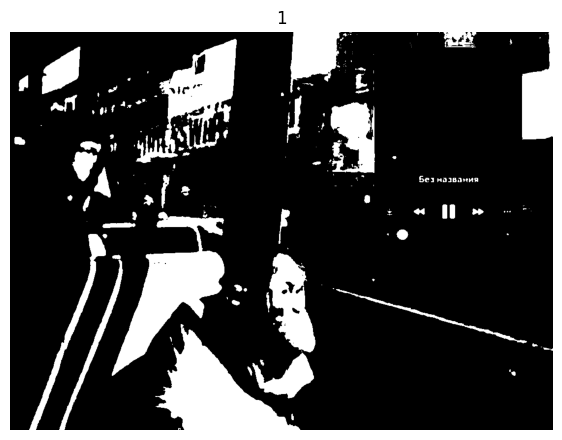

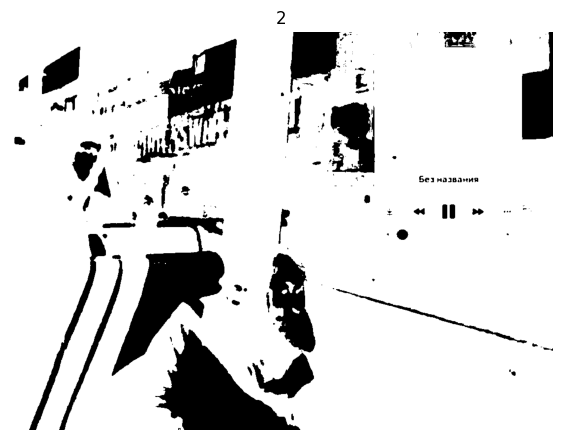

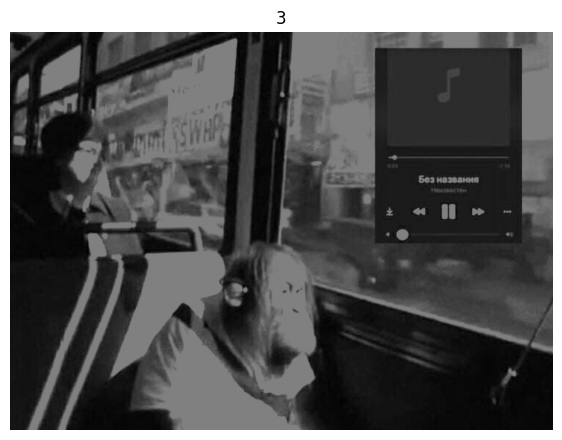

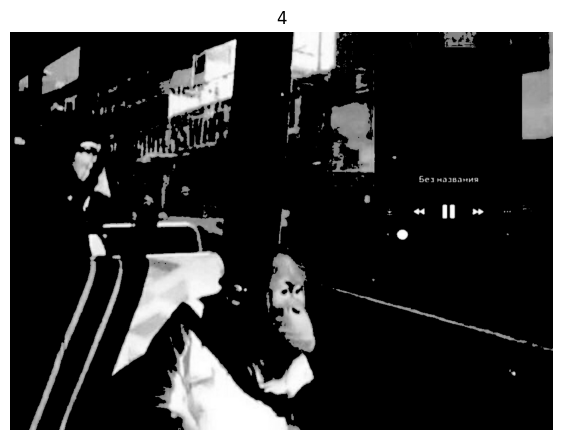

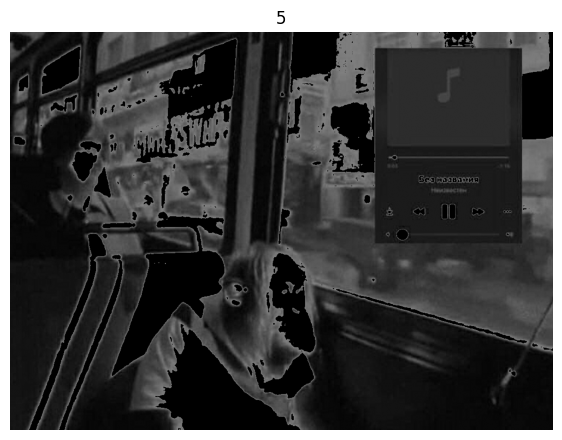

In [18]:
thres_modes = [cv2.THRESH_BINARY, cv2.THRESH_BINARY_INV, 
               cv2.THRESH_TRUNC, 
               cv2.THRESH_TOZERO, cv2.THRESH_TOZERO_INV]

for thres_mode in thres_modes:
    _, img_thres = cv2.threshold(img_grayscale, 128, 255, thres_mode)
    show_img(img_thres, thres_mode + 1, size = 7)

## 5. Комбинации тресхолдов и разных параметров

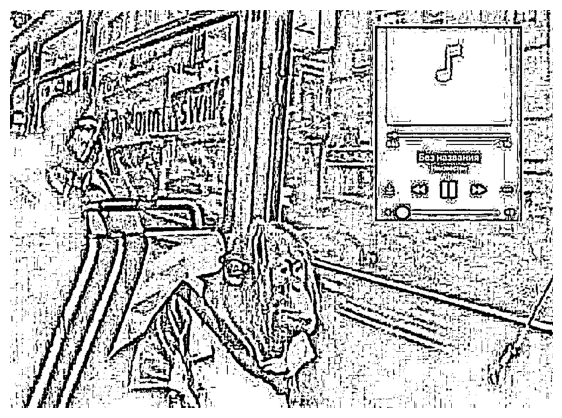

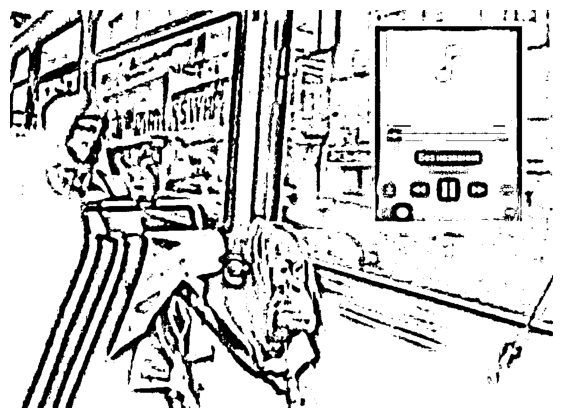

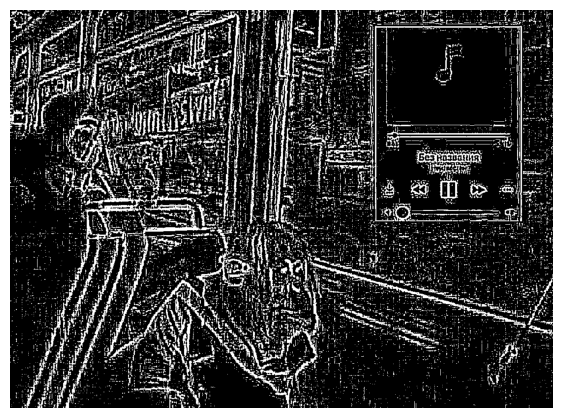

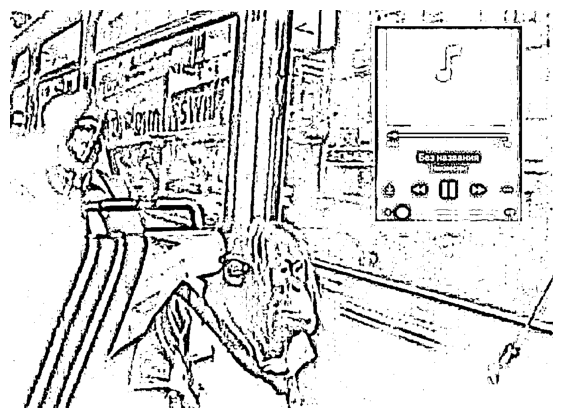

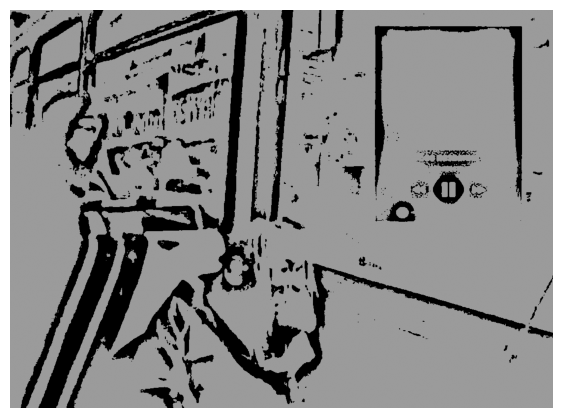

In [28]:
max_val = 255

# C - фильтр шума, чем выше, тем меньше посторонних черных пикселей
params = [
    (max_val, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 9, 2),
    (max_val, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 25, 9),
    (max_val, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV, 5, 2),
    (max_val, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 21, 5),
    (max_val-100, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 101, 20)
]

for i, (maxValue, type, mode, blockSize, Cval) in enumerate(params):
    img_adap = cv2.adaptiveThreshold(img_grayscale, maxValue, 
                                     type, mode, blockSize, Cval)
    show_img(img_adap, size = 7)


## 6. Фильтр Гаусса и бинаризация ОЦУ

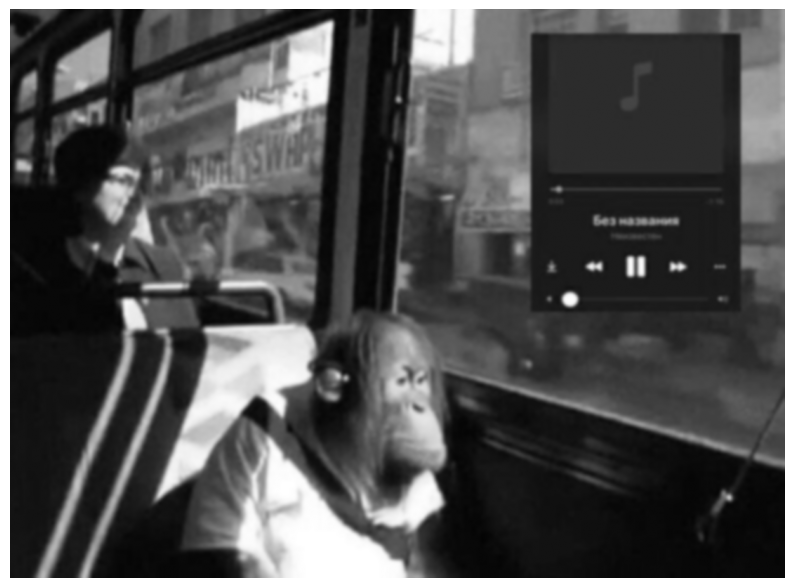

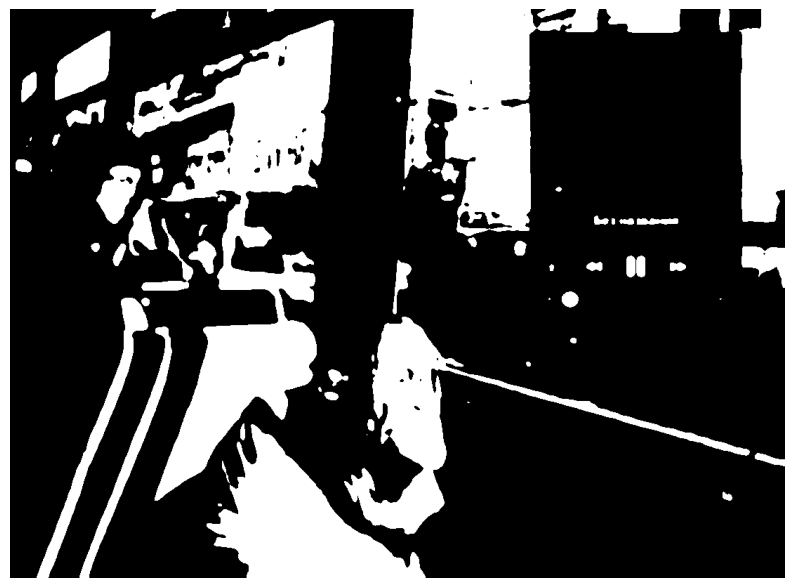

In [33]:
img_blur = cv2.GaussianBlur(img_grayscale, (11, 11), 0)
show_img(img_blur)
_, img_otsu = cv2.threshold(img_blur, 128, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
show_img(img_otsu)